# 09 Knowledge Graph Explainability
Этап 15: semantic / explainability layer поверх CatBoost recommendation core без обучения новых моделей.

## 1) Imports and config

In [2]:
import json
import importlib

import numpy as np
import pandas as pd

from _shared_notebook_utils import ROOT, RESEARCH_CHECKPOINT_DIR, save_json

nx = importlib.import_module("networkx")

RESULTS_DIR = ROOT / "artifacts" / "results" / "knowledge_graph_explainability"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("RESULTS_DIR =", RESULTS_DIR)

ROOT = C:\Users\Dmitry\code-projects\diploma-crop-rotation
RESULTS_DIR = C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\knowledge_graph_explainability


## 2) Load artifacts
Используем тот же подход, что в 06/07: model registry + baseline checkpoint split.

In [3]:
registry_path = ROOT / "artifacts" / "model_registry.json"
with open(registry_path, "r", encoding="utf-8") as f:
    registry = json.load(f)

active_model = registry["active_model"]
model_entry = registry["models"][active_model]
model_path = ROOT / model_entry["model_path"]
meta_path = ROOT / model_entry["meta_path"]

if not model_path.exists() or not meta_path.exists():
    raise FileNotFoundError(f"Model artifacts missing for active_model={active_model}: {model_path} / {meta_path}")

baseline_dir = RESEARCH_CHECKPOINT_DIR / "baseline"
train_df = pd.read_pickle(baseline_dir / "train_df.pkl")
val_df = pd.read_pickle(baseline_dir / "val_df.pkl")
test_df = pd.read_pickle(baseline_dir / "test_df.pkl")

with open(meta_path, "r", encoding="utf-8") as f:
    model_meta = json.load(f)

catboost_mod = importlib.import_module("catboost")
CatBoostClassifier = catboost_mod.CatBoostClassifier
model = CatBoostClassifier()
model.load_model(model_path.as_posix())

print("active_model =", active_model)
print("Loaded model:", model_path)
print("Loaded split shapes:", train_df.shape, val_df.shape, test_df.shape)

active_model = baseline
Loaded model: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\catboost\baseline\model.cbm
Loaded split shapes: (26957630, 12) (5776566, 12) (5777014, 12)


## 3) Validate required columns

In [4]:
required_train_cols = [
    "CSBID", "target_year",
    "history_1", "history_2", "history_3",
    "target", "STATEFIPS", "CNTYFIPS",
]
missing_train_cols = [c for c in required_train_cols if c not in train_df.columns]
if missing_train_cols:
    raise ValueError(f"Missing required columns in train_df: {missing_train_cols}")

for split_df in [train_df, val_df, test_df]:
    for col in ["history_1", "history_2", "history_3", "target", "STATEFIPS", "CNTYFIPS"]:
        if col in split_df.columns:
            split_df[col] = split_df[col].astype("string")

print("train_df columns validated.")
print("train_df shape =", train_df.shape)
print("val_df shape =", val_df.shape)
print("test_df shape =", test_df.shape)

train_df columns validated.
train_df shape = (26957630, 12)
val_df shape = (5776566, 12)
test_df shape = (5777014, 12)


## 4) Define semantic mappings

In [5]:
CROP_TO_GROUP = {
    "corn": "cereal",
    "wheat": "cereal",
    "sorghum": "cereal",
    "other_cereals": "cereal",
    "soybeans": "legume",
    "legumes": "legume",
    "forage_hay": "forage",
    "cotton": "industrial",
    "fallow": "fallow",
}

crop_group_df = pd.DataFrame([
    {"crop_name": crop, "crop_group": group}
    for crop, group in CROP_TO_GROUP.items()
]).sort_values(["crop_group", "crop_name"]).reset_index(drop=True)

display(crop_group_df)

,crop_name,crop_group
0,corn,cereal
1,other_cereals,cereal
2,sorghum,cereal
3,wheat,cereal
4,fallow,fallow
5,forage_hay,forage
6,cotton,industrial
7,legumes,legume
8,soybeans,legume


## 5) Build knowledge graph nodes

In [6]:
def make_region_id(statefips, cntyfips):
    return f"region_{statefips}_{cntyfips}"

crop_nodes = [
    {
        "node_id": f"crop_{crop}",
        "node_type": "Crop",
        "name": crop,
        "display_name": crop,
        "metadata_json": json.dumps({"crop_group": CROP_TO_GROUP.get(crop)}, ensure_ascii=False),
    }
    for crop in sorted(CROP_TO_GROUP.keys())
]

region_unique = (
    train_df[["STATEFIPS", "CNTYFIPS"]]
    .dropna()
    .astype({"STATEFIPS": "string", "CNTYFIPS": "string"})
    .drop_duplicates()
)
region_nodes = [
    {
        "node_id": make_region_id(row.STATEFIPS, row.CNTYFIPS),
        "node_type": "Region",
        "name": f"{row.STATEFIPS}_{row.CNTYFIPS}",
        "display_name": f"state={row.STATEFIPS}, county={row.CNTYFIPS}",
        "metadata_json": json.dumps({"STATEFIPS": str(row.STATEFIPS), "CNTYFIPS": str(row.CNTYFIPS)}, ensure_ascii=False),
    }
    for row in region_unique.itertuples(index=False)
]

group_nodes = [
    {
        "node_id": f"group_{group}",
        "node_type": "CropGroup",
        "name": group,
        "display_name": group,
        "metadata_json": json.dumps({}, ensure_ascii=False),
    }
    for group in sorted(set(CROP_TO_GROUP.values()))
]

rule_ids = [
    "rule_repeat_crop_penalty",
    "rule_same_group_saturation",
    "rule_legume_break_bonus",
    "rule_fallow_break_effect",
    "rule_region_typicality",
]
rule_nodes = [
    {
        "node_id": rule_id,
        "node_type": "Rule",
        "name": rule_id,
        "display_name": rule_id.replace("rule_", "").replace("_", " ").title(),
        "metadata_json": json.dumps({}, ensure_ascii=False),
    }
    for rule_id in rule_ids
]

nodes_df = pd.DataFrame(crop_nodes + region_nodes + group_nodes + rule_nodes)
nodes_df = nodes_df.drop_duplicates(subset=["node_id"]).reset_index(drop=True)

print("nodes_df shape =", nodes_df.shape)
display(nodes_df["node_type"].value_counts(dropna=False).rename_axis("node_type").reset_index(name="count"))

nodes_df shape = (2827, 5)


,node_type,count
0,Region,2808
1,Crop,9
2,CropGroup,5
3,Rule,5


## 6) Build knowledge graph edges

In [7]:
# 6.1 follows_after (Crop -> Crop), train-only
transition_counts = (
    train_df.groupby(["history_3", "target"], dropna=False)
    .size()
    .rename("transition_count")
    .reset_index()
    .dropna(subset=["history_3", "target"])
    .astype({"history_3": "string", "target": "string"})
)
transition_counts["transition_prob"] = (
    transition_counts["transition_count"]
    / transition_counts.groupby("history_3")["transition_count"].transform("sum")
)

transition_edges_df = transition_counts.rename(columns={"history_3": "last_crop", "target": "candidate"}).copy()
transition_edges_df["source_id"] = "crop_" + transition_edges_df["last_crop"].astype(str)
transition_edges_df["target_id"] = "crop_" + transition_edges_df["candidate"].astype(str)
transition_edges_df["edge_type"] = "follows_after"
transition_edges_df["weight"] = transition_edges_df["transition_prob"].astype(float)
transition_edges_df["support"] = transition_edges_df["transition_count"].astype(int)
transition_edges_df["note"] = "observed train transition"

display(transition_edges_df[["last_crop", "candidate", "transition_prob", "transition_count"]].head(15))

,last_crop,candidate,transition_prob,transition_count
0,corn,corn,0.309146,2459160
1,corn,cotton,0.016765,133363
2,corn,fallow,0.028365,225637
3,corn,forage_hay,0.017276,137429
4,corn,legumes,0.010607,84379
5,corn,other_cereals,0.014181,112804
6,corn,sorghum,0.012758,101485
7,corn,soybeans,0.562229,4472357
8,corn,wheat,0.028672,228075
9,cotton,corn,0.119207,140232


In [8]:
# 6.2 common_in_region (Region -> Crop), train-only
region_counts = (
    train_df.groupby(["STATEFIPS", "CNTYFIPS", "target"], dropna=False)
    .size()
    .rename("region_crop_count")
    .reset_index()
    .dropna(subset=["STATEFIPS", "CNTYFIPS", "target"])
    .astype({"STATEFIPS": "string", "CNTYFIPS": "string", "target": "string"})
)

region_counts["region_crop_share"] = (
    region_counts["region_crop_count"]
    / region_counts.groupby(["STATEFIPS", "CNTYFIPS"])["region_crop_count"].transform("sum")
)
region_counts["rank_in_region"] = region_counts.groupby(["STATEFIPS", "CNTYFIPS"])["region_crop_count"].rank(method="dense", ascending=False)

region_edges_df = region_counts.rename(columns={"target": "candidate"}).copy()
region_edges_df["region_id"] = region_edges_df.apply(lambda r: make_region_id(r["STATEFIPS"], r["CNTYFIPS"]), axis=1)
region_edges_df["source_id"] = region_edges_df["region_id"]
region_edges_df["target_id"] = "crop_" + region_edges_df["candidate"].astype(str)
region_edges_df["edge_type"] = "common_in_region"
region_edges_df["weight"] = region_edges_df["region_crop_share"].astype(float)
region_edges_df["support"] = region_edges_df["region_crop_count"].astype(int)
region_edges_df["note"] = "regional crop prevalence"

display(region_edges_df[["STATEFIPS", "CNTYFIPS", "candidate", "region_crop_share", "rank_in_region"]].head(15))

,STATEFIPS,CNTYFIPS,candidate,region_crop_share,rank_in_region
0,01,001,corn,0.130835,2.0
1,01,001,cotton,0.697313,1.0
2,01,001,fallow,0.000707,8.0
3,01,001,forage_hay,0.099010,3.0
4,01,001,other_cereals,0.002829,7.0
5,01,001,sorghum,0.010608,6.0
6,01,001,soybeans,0.045262,4.0
7,01,001,wheat,0.013437,5.0
8,01,003,corn,0.158481,4.0
9,01,003,cotton,0.234093,2.0


In [9]:
# 6.3 belongs_to_group and rule links
belongs_edges_df = pd.DataFrame([
    {
        "source_id": f"crop_{crop}",
        "target_id": f"group_{group}",
        "edge_type": "belongs_to_group",
        "weight": 1.0,
        "support": np.nan,
        "note": "semantic crop grouping",
    }
    for crop, group in CROP_TO_GROUP.items()
])

all_crops = sorted(CROP_TO_GROUP.keys())
cereal_crops = ["corn", "wheat", "sorghum", "other_cereals"]

rule_links = []

for crop in ["soybeans", "legumes"]:
    rule_links.append({"rule_id": "rule_legume_break_bonus", "crop": crop, "edge_type": "supports_candidate"})
for crop in cereal_crops:
    rule_links.append({"rule_id": "rule_same_group_saturation", "crop": crop, "edge_type": "warns_about_candidate"})
for crop in all_crops:
    rule_links.append({"rule_id": "rule_region_typicality", "crop": crop, "edge_type": "supports_candidate"})
for crop in all_crops:
    rule_links.append({"rule_id": "rule_repeat_crop_penalty", "crop": crop, "edge_type": "warns_about_candidate"})
for crop in all_crops:
    if crop == "fallow":
        rule_links.append({"rule_id": "rule_fallow_break_effect", "crop": crop, "edge_type": "warns_about_candidate"})
    else:
        rule_links.append({"rule_id": "rule_fallow_break_effect", "crop": crop, "edge_type": "supports_candidate"})

rule_edges_df = pd.DataFrame(rule_links)
rule_edges_df["source_id"] = rule_edges_df["rule_id"]
rule_edges_df["target_id"] = "crop_" + rule_edges_df["crop"].astype(str)
rule_edges_df["weight"] = 1.0
rule_edges_df["support"] = np.nan
rule_edges_df["note"] = "semantic rule link"

edge_cols = ["source_id", "target_id", "edge_type", "weight", "support", "note"]
edges_df = pd.concat([
    transition_edges_df[edge_cols],
    region_edges_df[edge_cols],
    belongs_edges_df[edge_cols],
    rule_edges_df[edge_cols],
], ignore_index=True)
edges_df = edges_df.drop_duplicates().reset_index(drop=True)

print("edges_df shape =", edges_df.shape)
display(edges_df["edge_type"].value_counts(dropna=False).rename_axis("edge_type").reset_index(name="count"))

edges_df shape = (18154, 6)


,edge_type,count
0,common_in_region,17950
1,follows_after,162
2,supports_candidate,19
3,warns_about_candidate,14
4,belongs_to_group,9


## 7) Build rule layer

In [10]:
rules_df = pd.DataFrame([
    {
        "rule_id": "rule_repeat_crop_penalty",
        "rule_name": "repeat_crop_penalty",
        "rule_type": "warning",
        "description": "Warn if candidate repeats the last crop.",
        "logic_comment": "candidate == history_3",
    },
    {
        "rule_id": "rule_same_group_saturation",
        "rule_name": "same_group_saturation",
        "rule_type": "warning",
        "description": "Warn when history is group-saturated and candidate stays in same group.",
        "logic_comment": "dominant history group ratio >= 0.67 and candidate group == dominant group",
    },
    {
        "rule_id": "rule_legume_break_bonus",
        "rule_name": "legume_break_bonus",
        "rule_type": "support",
        "description": "Support legume candidates if recent history has no legumes.",
        "logic_comment": "candidate in {soybeans, legumes} and no legume in history",
    },
    {
        "rule_id": "rule_fallow_break_effect",
        "rule_name": "fallow_break_effect",
        "rule_type": "support_or_warning",
        "description": "Support return from fallow, warn on repeated fallow.",
        "logic_comment": "if fallow in history and candidate!=fallow -> support; if candidate==fallow and fallow in history -> warning",
    },
    {
        "rule_id": "rule_region_typicality",
        "rule_name": "region_typicality",
        "rule_type": "support",
        "description": "Support candidates that are typical for the region.",
        "logic_comment": "candidate rank_in_region <= 3 based on train statistics",
    },
])

display(rules_df)

,rule_id,rule_name,rule_type,description,logic_comment
0,rule_repeat_crop_penalty,repeat_crop_penalty,warning,Warn if candidate repeats the last crop.,candidate == history_3
1,rule_same_group_saturation,same_group_saturation,warning,Warn when history is group-saturated and candi...,dominant history group ratio >= 0.67 and candi...
2,rule_legume_break_bonus,legume_break_bonus,support,Support legume candidates if recent history ha...,"candidate in {soybeans, legumes} and no legume..."
3,rule_fallow_break_effect,fallow_break_effect,support_or_warning,"Support return from fallow, warn on repeated f...",if fallow in history and candidate!=fallow -> ...
4,rule_region_typicality,region_typicality,support,Support candidates that are typical for the re...,candidate rank_in_region <= 3 based on train s...


## 8) Save graph artifacts

In [11]:
nodes_df.to_csv(RESULTS_DIR / "kg_nodes.csv", index=False)
edges_df.to_csv(RESULTS_DIR / "kg_edges.csv", index=False)
rules_df.to_csv(RESULTS_DIR / "kg_rules.csv", index=False)

nodes_df.to_pickle(RESULTS_DIR / "kg_nodes.pkl")
edges_df.to_pickle(RESULTS_DIR / "kg_edges.pkl")
rules_df.to_pickle(RESULTS_DIR / "kg_rules.pkl")

transition_edges_df.to_csv(RESULTS_DIR / "transition_edges.csv", index=False)
region_edges_df.to_csv(RESULTS_DIR / "region_edges.csv", index=False)

print("Saved graph artifacts to:", RESULTS_DIR)

Saved graph artifacts to: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\knowledge_graph_explainability


## 9) Build explainability helpers

In [12]:
transition_lookup = {
    (str(r.last_crop), str(r.candidate)): {
        "transition_prob": float(r.transition_prob),
        "transition_support": int(r.transition_count),
    }
    for r in transition_edges_df[["last_crop", "candidate", "transition_prob", "transition_count"]].itertuples(index=False)
}

region_lookup = {
    (str(r.region_id), str(r.candidate)): {
        "region_share": float(r.region_crop_share),
        "region_support": int(r.region_crop_count),
        "region_rank": int(r.rank_in_region),
    }
    for r in region_edges_df[["region_id", "candidate", "region_crop_share", "region_crop_count", "rank_in_region"]].itertuples(index=False)
}

def get_crop_group(crop_name):
    return CROP_TO_GROUP.get(str(crop_name), "unknown")

def get_transition_fact(last_crop, candidate, transition_edges_df):
    _ = transition_edges_df
    return transition_lookup.get((str(last_crop), str(candidate)))

def get_region_fact(statefips, cntyfips, candidate, region_edges_df):
    _ = region_edges_df
    region_id = make_region_id(statefips, cntyfips)
    return region_lookup.get((region_id, str(candidate)))

def evaluate_rules_for_candidate(sample_row, candidate, crop_to_group, region_edges_df):
    support_flags = []
    warning_flags = []

    h1 = str(sample_row.get("history_1", ""))
    h2 = str(sample_row.get("history_2", ""))
    h3 = str(sample_row.get("history_3", ""))
    history = [h1, h2, h3]
    cand = str(candidate)

    if cand == h3:
        warning_flags.append("repeat_crop_penalty")

    hist_groups = [crop_to_group.get(c) for c in history if c in crop_to_group]
    if hist_groups:
        group_counts = pd.Series(hist_groups).value_counts()
        dominant_group = str(group_counts.index[0])
        dominant_ratio = float(group_counts.iloc[0] / len(hist_groups))
        if dominant_ratio >= 0.67 and crop_to_group.get(cand) == dominant_group:
            warning_flags.append("same_group_saturation")

    has_legume_recently = any(crop_to_group.get(c) == "legume" for c in history)
    if (not has_legume_recently) and cand in {"soybeans", "legumes"}:
        support_flags.append("legume_break_bonus")

    has_fallow_recently = "fallow" in history
    if has_fallow_recently and cand != "fallow":
        support_flags.append("fallow_break_effect")
    if has_fallow_recently and cand == "fallow":
        warning_flags.append("fallow_break_effect")

    region_fact = get_region_fact(sample_row.get("STATEFIPS"), sample_row.get("CNTYFIPS"), cand, region_edges_df)
    if region_fact is not None and region_fact["region_rank"] <= 3:
        support_flags.append("region_typicality")

    return support_flags, warning_flags

def get_topk_predictions(model, X, class_names, k=3):
    proba = np.asarray(model.predict_proba(X))
    k = min(int(k), proba.shape[1])
    top_idx_unsorted = np.argpartition(proba, -k, axis=1)[:, -k:]
    top_proba_unsorted = np.take_along_axis(proba, top_idx_unsorted, axis=1)
    sort_order = np.argsort(-top_proba_unsorted, axis=1)
    top_idx = np.take_along_axis(top_idx_unsorted, sort_order, axis=1)
    top_scores = np.take_along_axis(top_proba_unsorted, sort_order, axis=1)
    class_arr = np.asarray(class_names, dtype=object)
    top_labels = class_arr[top_idx]
    return top_labels, top_scores

def build_explanation_for_sample(sample_row, topk_candidates, topk_scores, transition_edges_df, region_edges_df, crop_to_group):
    rows = []
    last_crop = str(sample_row.get("history_3"))
    statefips = sample_row.get("STATEFIPS")
    cntyfips = sample_row.get("CNTYFIPS")

    for cand, score in zip(topk_candidates, topk_scores):
        cand = str(cand)
        t_fact = get_transition_fact(last_crop, cand, transition_edges_df)
        r_fact = get_region_fact(statefips, cntyfips, cand, region_edges_df)
        support_flags, warning_flags = evaluate_rules_for_candidate(sample_row, cand, crop_to_group, region_edges_df)

        phrases = []
        if t_fact is not None:
            phrases.append(f"Observed transition {last_crop} -> {cand} in train data (p={t_fact['transition_prob']:.3f}).")
        if r_fact is not None and r_fact["region_rank"] <= 3:
            phrases.append("Candidate is common in the current region.")
        phrases.append(f"Candidate belongs to {get_crop_group(cand)} group.")
        if "legume_break_bonus" in support_flags:
            phrases.append("Rule legume_break_bonus is activated.")
        if "repeat_crop_penalty" in warning_flags:
            phrases.append("Warning: candidate repeats the last crop.")
        if "same_group_saturation" in warning_flags:
            phrases.append("Warning: group-saturated history may continue.")

        rows.append({
            "candidate": cand,
            "score": float(score),
            "crop_group": get_crop_group(cand),
            "transition_prob": None if t_fact is None else float(t_fact["transition_prob"]),
            "transition_support": None if t_fact is None else int(t_fact["transition_support"]),
            "region_share": None if r_fact is None else float(r_fact["region_share"]),
            "region_rank": None if r_fact is None else int(r_fact["region_rank"]),
            "support_flags": support_flags,
            "warning_flags": warning_flags,
            "short_explanation": " ".join(phrases[:3]),
        })

    return pd.DataFrame(rows)

## 10) Generate explainable recommendation examples

In [13]:
feature_columns = model_meta.get("feature_columns", model_meta.get("feature_cols", []))
if not feature_columns:
    raise ValueError("feature columns are missing in model meta")

if "id_to_target" in model_meta:
    id_to_target = {int(k): str(v) for k, v in model_meta["id_to_target"].items()}
    class_names = [id_to_target[i] for i in sorted(id_to_target.keys())]
elif "target_to_id" in model_meta:
    inv = {int(v): str(k) for k, v in model_meta["target_to_id"].items()}
    class_names = [inv[i] for i in sorted(inv.keys())]
else:
    raise ValueError("No class mapping found in model meta")

missing_features = [c for c in feature_columns if c not in test_df.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns in test_df: {missing_features}")

pool_n = min(5000, len(test_df))
case_pool = test_df.sample(n=pool_n, random_state=42).copy()

for col in ["history_1", "history_2", "history_3", "STATEFIPS", "CNTYFIPS", "target"]:
    if col in case_pool.columns:
        case_pool[col] = case_pool[col].astype("string")

top_labels_pool, top_scores_pool = get_topk_predictions(model, case_pool[feature_columns], class_names, k=3)
case_pool["top1_pred"] = top_labels_pool[:, 0]
case_pool["top1_proba"] = top_scores_pool[:, 0].astype(float)
case_pool["is_top1_correct"] = (case_pool["top1_pred"].astype(str) == case_pool["target"].astype(str))

case_pool["confidence_bucket"] = np.select(
    [case_pool["top1_proba"] >= 0.75, case_pool["top1_proba"] >= 0.45],
    ["high", "medium"],
    default="low",
)

difficult_targets = {"legumes", "sorghum", "other_cereals", "fallow"}
selected_indices = []

def pick_first(mask):
    candidates = case_pool[mask]
    if candidates.empty:
        return None
    for idx in candidates.index.tolist():
        if idx not in selected_indices:
            return idx
    return None

idx_high = pick_first((case_pool["confidence_bucket"] == "high") & (case_pool["is_top1_correct"]))
idx_medium = pick_first(case_pool["confidence_bucket"] == "medium")
idx_low = pick_first(case_pool["confidence_bucket"] == "low")
idx_difficult = pick_first(case_pool["target"].astype(str).isin(difficult_targets))

for idx in [idx_high, idx_medium, idx_low, idx_difficult]:
    if idx is not None and idx not in selected_indices:
        selected_indices.append(idx)

if len(selected_indices) < 4:
    for idx in case_pool.index.tolist():
        if idx not in selected_indices:
            selected_indices.append(idx)
        if len(selected_indices) >= 4:
            break

case_labels = ["case_high_confidence", "case_medium_confidence", "case_low_confidence", "case_difficult_class"]
case_studies = []
for label, idx in zip(case_labels, selected_indices[:4]):
    pos = int(np.where(case_pool.index.to_numpy() == idx)[0][0])
    sample_row = case_pool.loc[idx]
    candidates = top_labels_pool[pos, :3].tolist()
    scores = top_scores_pool[pos, :3].tolist()
    explanation_df = build_explanation_for_sample(sample_row, candidates, scores, transition_edges_df, region_edges_df, CROP_TO_GROUP)
    case_studies.append({
        "label": label,
        "index": int(idx),
        "sample_row": sample_row,
        "topk_candidates": candidates,
        "topk_scores": scores,
        "explanation_df": explanation_df,
    })

print("Selected case studies:")
for case in case_studies:
    row = case["sample_row"]
    print("-", case["label"], "| target =", row.get("target"), "| top1_proba =", float(case["topk_scores"][0]))
    sample_info = pd.DataFrame([{
        "CSBID": row.get("CSBID"),
        "target_year": row.get("target_year"),
        "history_1": row.get("history_1"),
        "history_2": row.get("history_2"),
        "history_3": row.get("history_3"),
        "target": row.get("target"),
        "STATEFIPS": row.get("STATEFIPS"),
        "CNTYFIPS": row.get("CNTYFIPS"),
    }])
    display(sample_info)
    display(case["explanation_df"])
    print("Interpretation:", case["explanation_df"]["short_explanation"].iloc[0])

Selected case studies:
- case_high_confidence | target = forage_hay | top1_proba = 0.9299050742261123


,CSBID,target_year,history_1,history_2,history_3,target,STATEFIPS,CNTYFIPS
0,061724015942187,2023,legumes,forage_hay,forage_hay,forage_hay,06,095


,candidate,score,crop_group,transition_prob,transition_support,region_share,region_rank,support_flags,warning_flags,short_explanation
0,forage_hay,0.929905,forage,0.820376,2179252,0.534522,1,[region_typicality],[repeat_crop_penalty],Observed transition forage_hay -> forage_hay i...
1,corn,0.024482,cereal,0.097016,257714,0.064586,4,[],[],Observed transition forage_hay -> corn in trai...
2,wheat,0.020871,cereal,0.027639,73421,0.161656,3,[region_typicality],[],Observed transition forage_hay -> wheat in tra...


Interpretation: Observed transition forage_hay -> forage_hay in train data (p=0.820). Candidate is common in the current region. Candidate belongs to forage group.
- case_medium_confidence | target = corn | top1_proba = 0.6687763965689583


,CSBID,target_year,history_1,history_2,history_3,target,STATEFIPS,CNTYFIPS
0,551724008089019,2022,forage_hay,forage_hay,corn,corn,55,087


...

,candidate,score,crop_group,transition_prob,transition_support,region_share,region_rank,support_flags,warning_flags,short_explanation
0,legumes,0.432215,legume,0.010607,84379,0.017557,6,[],[],Observed transition corn -> legumes in train d...
1,soybeans,0.368545,legume,0.562229,4472357,0.491151,1,[region_typicality],[],Observed transition corn -> soybeans in train ...
2,fallow,0.081568,fallow,0.028365,225637,0.127309,3,[region_typicality],[],Observed transition corn -> fallow in train da...


Interpretation: Observed transition corn -> legumes in train data (p=0.011). Candidate belongs to legume group.
- case_difficult_class | target = soybeans | top1_proba = 0.6886739742358626


,CSBID,target_year,history_1,history_2,history_3,target,STATEFIPS,CNTYFIPS
0,051724006228676,2021,corn,corn,cotton,soybeans,05,043


,candidate,score,crop_group,transition_prob,transition_support,region_share,region_rank,support_flags,warning_flags,short_explanation
0,corn,0.688674,cereal,0.119207,140232,0.178996,2,[region_typicality],[],Observed transition cotton -> corn in train da...
1,cotton,0.211758,industrial,0.626541,737047,0.160724,3,[region_typicality],[repeat_crop_penalty],Observed transition cotton -> cotton in train ...
2,soybeans,0.083540,legume,0.061005,71765,0.585950,1,"[legume_break_bonus, region_typicality]",[],Observed transition cotton -> soybeans in trai...


Interpretation: Observed transition cotton -> corn in train data (p=0.119). Candidate is common in the current region. Candidate belongs to cereal group.


## 12) Visualize graph subgraphs
Рисуем локальные explainability subgraphs для выбранных кейсов (networkx + matplotlib).

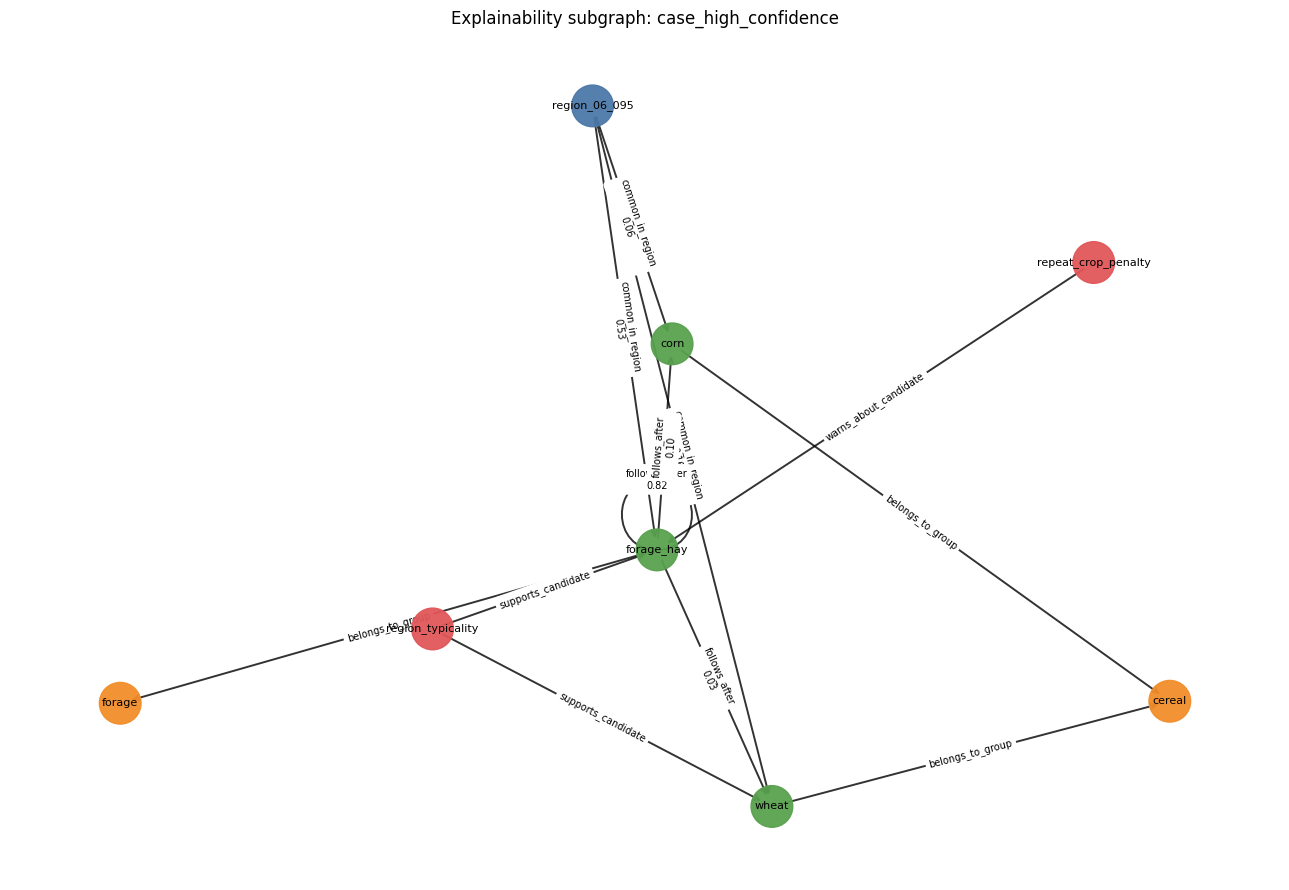

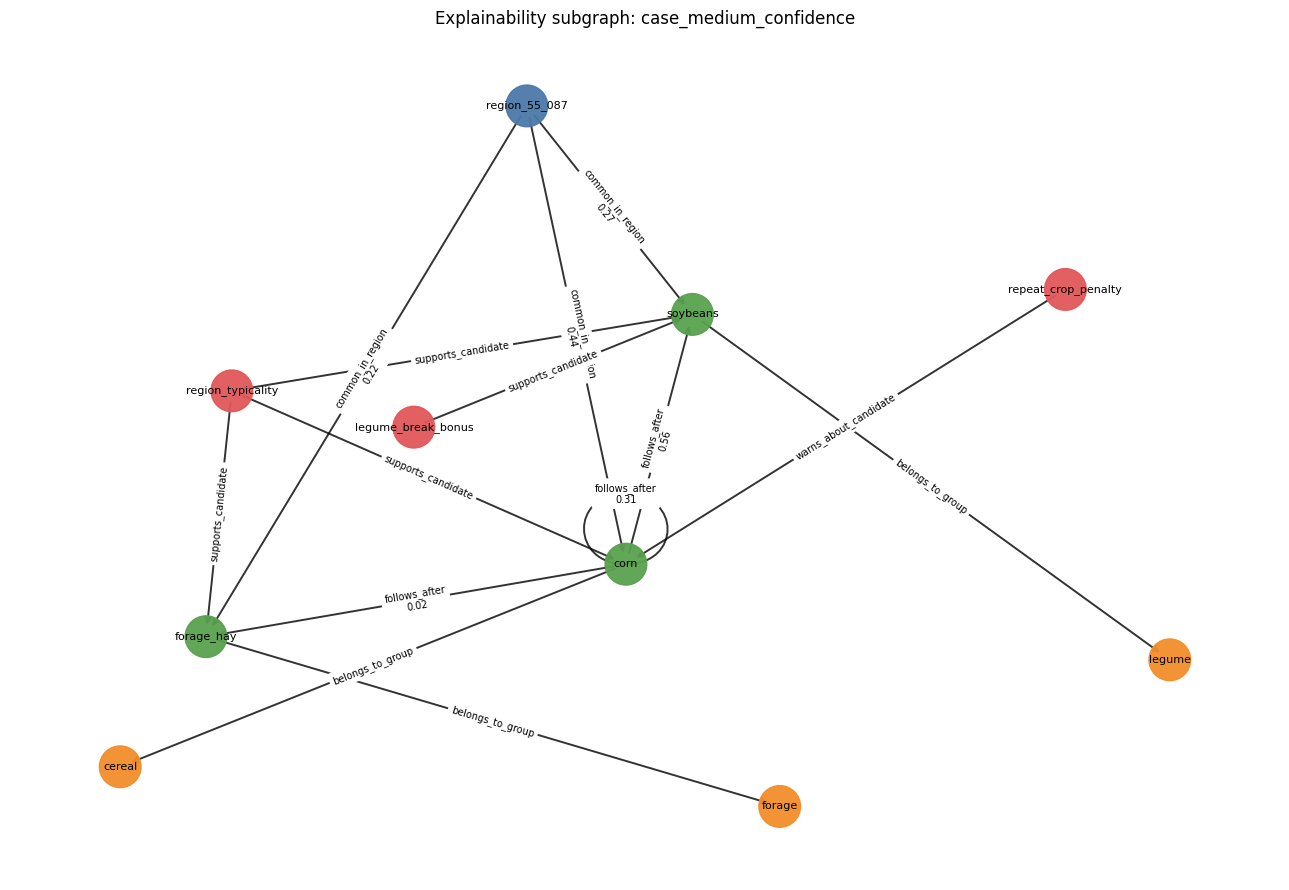

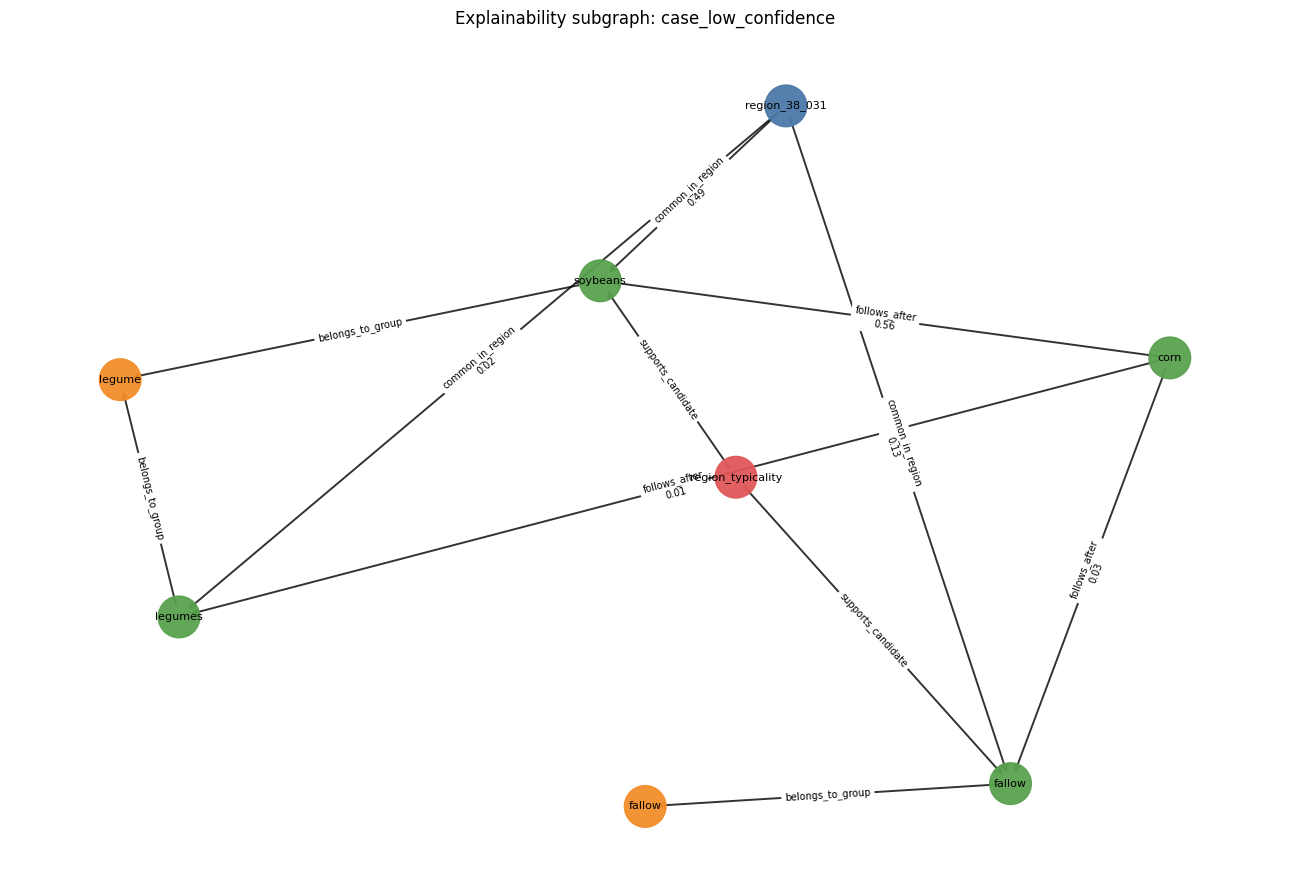

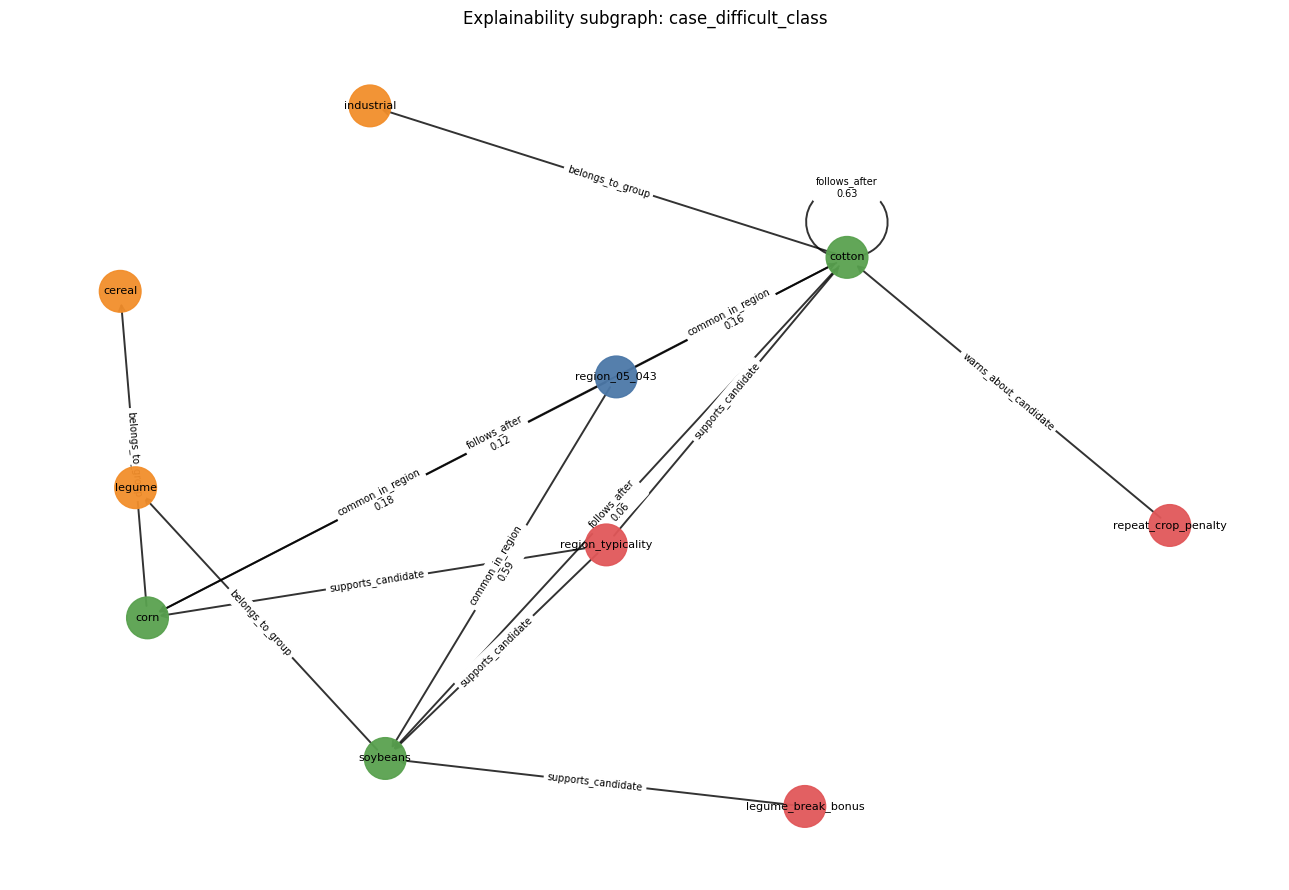

,case_label,figure_path
0,case_high_confidence,C:\Users\Dmitry\code-projects\diploma-crop-rot...
1,case_medium_confidence,C:\Users\Dmitry\code-projects\diploma-crop-rot...
2,case_low_confidence,C:\Users\Dmitry\code-projects\diploma-crop-rot...
3,case_difficult_class,C:\Users\Dmitry\code-projects\diploma-crop-rot...


In [14]:
import matplotlib.pyplot as plt

def draw_case_subgraph(case_label, sample_row, explanation_df, save_path):
    G = nx.DiGraph()

    region_id = make_region_id(sample_row.get("STATEFIPS"), sample_row.get("CNTYFIPS"))
    last_crop = str(sample_row.get("history_3"))
    last_crop_id = f"crop_{last_crop}"

    G.add_node(region_id, node_type="Region", label=region_id)
    G.add_node(last_crop_id, node_type="Crop", label=last_crop)

    for r in explanation_df.itertuples(index=False):
        cand = str(r.candidate)
        cand_id = f"crop_{cand}"
        group_id = f"group_{r.crop_group}"

        G.add_node(cand_id, node_type="Crop", label=cand)
        G.add_node(group_id, node_type="CropGroup", label=str(r.crop_group))
        G.add_edge(cand_id, group_id, edge_type="belongs_to_group", weight=1.0)

        t_fact = get_transition_fact(last_crop, cand, transition_edges_df)
        if t_fact is not None:
            G.add_edge(last_crop_id, cand_id, edge_type="follows_after", weight=float(t_fact["transition_prob"]))

        r_fact = get_region_fact(sample_row.get("STATEFIPS"), sample_row.get("CNTYFIPS"), cand, region_edges_df)
        if r_fact is not None:
            G.add_edge(region_id, cand_id, edge_type="common_in_region", weight=float(r_fact["region_share"]))

        support_flags = r.support_flags if isinstance(r.support_flags, list) else []
        warning_flags = r.warning_flags if isinstance(r.warning_flags, list) else []

        for flag in support_flags:
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag)
            G.add_edge(rule_node, cand_id, edge_type="supports_candidate", weight=1.0)

        for flag in warning_flags:
            rule_node = f"rule_{flag}"
            G.add_node(rule_node, node_type="Rule", label=flag)
            G.add_edge(rule_node, cand_id, edge_type="warns_about_candidate", weight=1.0)

    plt.figure(figsize=(13, 9))
    pos = nx.spring_layout(G, seed=42, k=1.2)

    color_map = []
    labels = {}
    for n, data in G.nodes(data=True):
        labels[n] = data.get("label", n)
        ntype = data.get("node_type", "Other")
        if ntype == "Region":
            color_map.append("#4C78A8")
        elif ntype == "Crop":
            color_map.append("#59A14F")
        elif ntype == "CropGroup":
            color_map.append("#F28E2B")
        elif ntype == "Rule":
            color_map.append("#E15759")
        else:
            color_map.append("#BDBDBD")

    nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=900, alpha=0.95)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", width=1.4, alpha=0.8)

    edge_labels = {}
    for u, v, data in G.edges(data=True):
        e_type = data.get("edge_type", "")
        weight = data.get("weight")
        if e_type in {"follows_after", "common_in_region"} and weight is not None:
            edge_labels[(u, v)] = f"{e_type}\n{weight:.2f}"
        else:
            edge_labels[(u, v)] = e_type

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.title(f"Explainability subgraph: {case_label}")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180)
    plt.show()

figure_rows = []
for case in case_studies[:4]:
    fig_path = FIGURES_DIR / f"{case['label']}.png"
    draw_case_subgraph(case["label"], case["sample_row"], case["explanation_df"], fig_path)
    figure_rows.append({"case_label": case["label"], "figure_path": str(fig_path)})

figures_df = pd.DataFrame(figure_rows)
display(figures_df)

## 13) Final summary

In [15]:
cases_export_rows = []
for case in case_studies:
    tmp = case["explanation_df"].copy()
    tmp.insert(0, "case_label", case["label"])
    tmp.insert(1, "case_index", case["index"])
    cases_export_rows.append(tmp)

case_explanations_df = pd.concat(cases_export_rows, ignore_index=True) if cases_export_rows else pd.DataFrame()
case_explanations_df.to_csv(RESULTS_DIR / "case_explanations.csv", index=False)

run_meta = {
    "active_model": active_model,
    "model_path": str(model_path),
    "meta_path": str(meta_path),
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "nodes_count": int(len(nodes_df)),
    "edges_count": int(len(edges_df)),
    "rules_count": int(len(rules_df)),
    "figures_count": int(len(figures_df)),
}
save_json(run_meta, RESULTS_DIR / "run_meta.json")

print("Knowledge graph artifacts ready in:", RESULTS_DIR)
print("CatBoost remains predictive core. KG + rules provide semantic and explainability layer only.")
display(pd.DataFrame([{
    "artifact": "kg_nodes.csv", "rows": len(nodes_df)
}, {
    "artifact": "kg_edges.csv", "rows": len(edges_df)
}, {
    "artifact": "kg_rules.csv", "rows": len(rules_df)
}, {
    "artifact": "case_explanations.csv", "rows": len(case_explanations_df)
}]))

Knowledge graph artifacts ready in: C:\Users\Dmitry\code-projects\diploma-crop-rotation\artifacts\results\knowledge_graph_explainability
CatBoost remains predictive core. KG + rules provide semantic and explainability layer only.


,artifact,rows
0,kg_nodes.csv,2827
1,kg_edges.csv,18154
2,kg_rules.csv,5
3,case_explanations.csv,12
